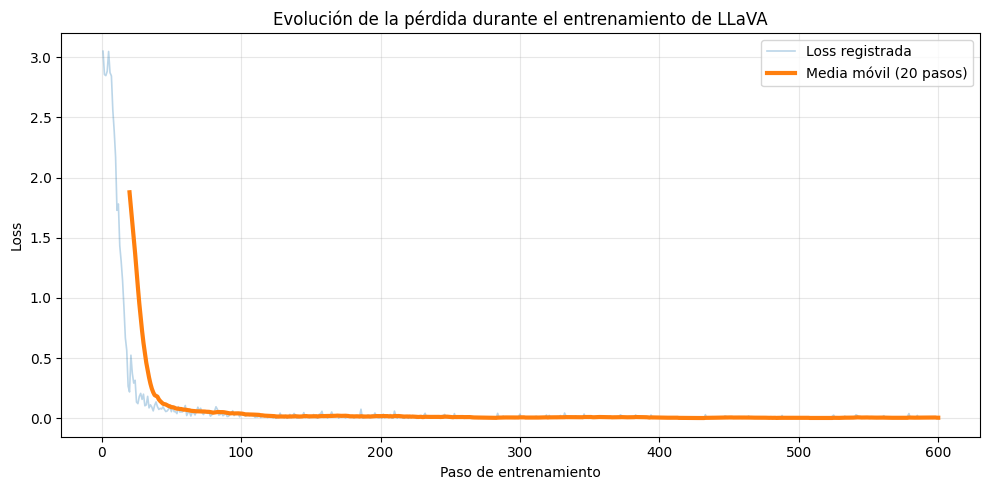

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# Cargar trainer_state.json
# ==========================
with open("trainer_state.json", "r", encoding="utf-8") as f:
    trainer = json.load(f)

# ==========================
# Extraer pérdidas
# ==========================
datos = []

for registro in trainer["log_history"]:
    if "loss" in registro:
        datos.append({
            "Paso": registro["step"],
            "Loss": registro["loss"]
        })

df = pd.DataFrame(datos)

# ==========================
# Media móvil
# ==========================
ventana = 20
df["Loss suavizada"] = df["Loss"].rolling(window=ventana).mean()

# ==========================
# Gráfica
# ==========================
plt.figure(figsize=(10,5))

plt.plot(
    df["Paso"],
    df["Loss"],
    alpha=0.30,
    linewidth=1.2,
    label="Loss registrada"
)

plt.plot(
    df["Paso"],
    df["Loss suavizada"],
    linewidth=3,
    label="Media móvil (20 pasos)"
)

plt.title("Evolución de la pérdida durante el entrenamiento de LLaVA")

plt.xlabel("Paso de entrenamiento")

plt.ylabel("Loss")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
print("Resumen del entrenamiento\n")

print(f"Loss inicial : {df['Loss'].iloc[0]:.4f}")
print(f"Loss final   : {df['Loss'].iloc[-1]:.4f}")
print(f"Loss mínima  : {df['Loss'].min():.4f}")
print(f"Loss máxima  : {df['Loss'].max():.4f}")
print(f"Promedio     : {df['Loss'].mean():.4f}")
print(f"Pasos        : {len(df)}")

Resumen del entrenamiento

Loss inicial : 3.0495
Loss final   : 0.0001
Loss mínima  : 0.0001
Loss máxima  : 3.0495
Promedio     : 0.0820
Pasos        : 600
